# CRISP-DM: Predicting Fraud in Shop Orders
## Assignment 17.11 — Part 2

**Business Problem:** Predict whether an order is fraudulent (`is_fraud`) using customer, order, and product features from `shop.db`.

**CRISP-DM Phases:**
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

---
## 1. Business Understanding

### Problem Definition
E-commerce fraud directly reduces revenue, increases chargeback costs, and damages customer trust. The goal is to build a binary classifier that flags suspicious orders as fraudulent (`is_fraud = 1`) before they are fulfilled.

### Success Criteria
- **Primary metric:** F1-score (balances precision and recall on an imbalanced class)
- **Secondary metric:** ROC-AUC (measures rank-order discrimination)
- **Target:** F1 ≥ 0.70, ROC-AUC ≥ 0.75
- A false negative (missing fraud) is more costly than a false positive (flagging a legitimate order), so we'll tune toward higher recall.

### Deployment Context
The trained model will be serialized and integrated into the operational pipeline alongside the late-delivery model. It can be run on new orders to assign a fraud risk score, complementing the existing `risk_score` feature already computed by the system.

---
## 2. Data Understanding

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DB_PATH = "shop.db"
conn = sqlite3.connect(DB_PATH)

orders = pd.read_sql("SELECT * FROM orders", conn)
customers = pd.read_sql("SELECT * FROM customers", conn)
order_items = pd.read_sql("SELECT * FROM order_items", conn)
products = pd.read_sql("SELECT * FROM products", conn)

conn.close()

print(f"orders:      {orders.shape}")
print(f"customers:   {customers.shape}")
print(f"order_items: {order_items.shape}")
print(f"products:    {products.shape}")
orders.head(3)

orders:      (5000, 17)
customers:   (250, 12)
order_items: (15022, 6)
products:    (100, 7)


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,None,662.95,15.44,46.30,724.69,38.3,0
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,SAVE10,862.92,14.74,66.61,944.27,94.9,0
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,None,796.09,14.04,40.72,850.85,53.8,1


Fraud rate: 6.36%
is_fraud
0    4682
1     318
Name: count, dtype: int64


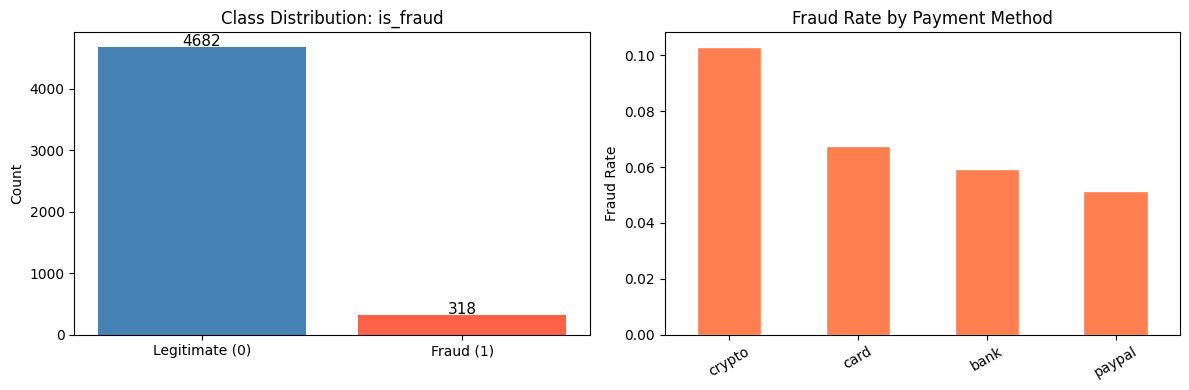

In [2]:
# Target class distribution
fraud_counts = orders["is_fraud"].value_counts()
fraud_rate = orders["is_fraud"].mean()
print(f"Fraud rate: {fraud_rate:.2%}")
print(fraud_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
axes[0].bar(["Legitimate (0)", "Fraud (1)"], fraud_counts.values, color=["steelblue", "tomato"])
axes[0].set_title("Class Distribution: is_fraud")
axes[0].set_ylabel("Count")
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontsize=11)

# Fraud rate by payment method
fraud_by_payment = orders.groupby("payment_method")["is_fraud"].mean().sort_values(ascending=False)
fraud_by_payment.plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Fraud Rate by Payment Method")
axes[1].set_ylabel("Fraud Rate")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

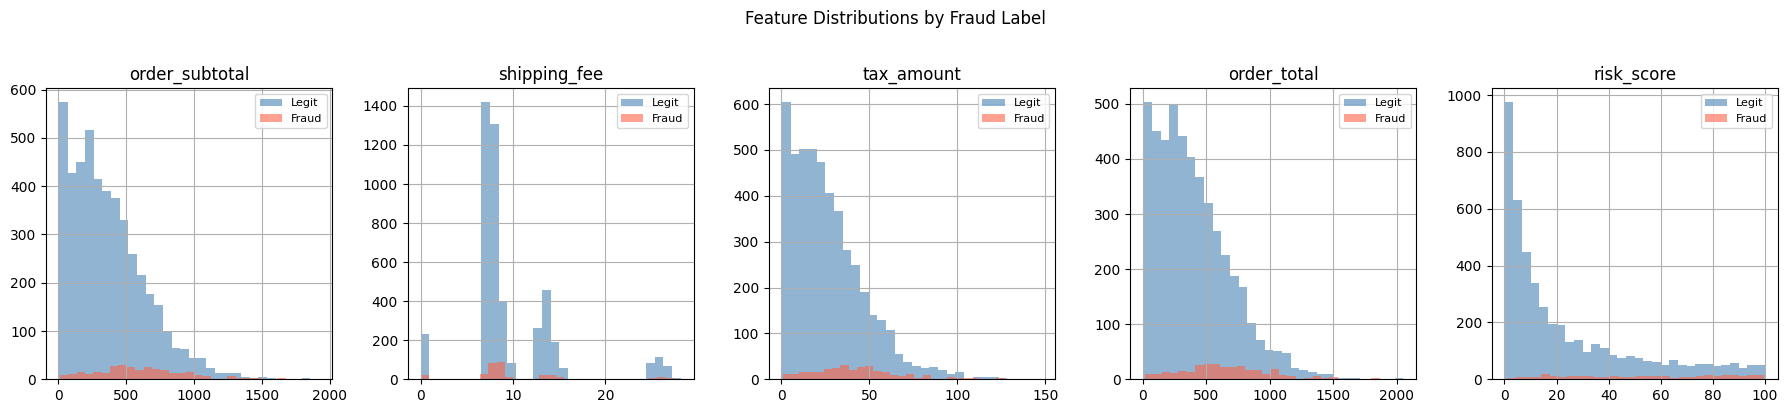


Mean values by fraud label:


,order_subtotal,shipping_fee,tax_amount,order_total,risk_score
is_fraud,,,,,
0,368.86,9.65,26.64,405.15,24.19
1,609.21,9.96,43.84,663.00,54.54


In [3]:
# Explore numeric feature distributions by fraud label
numeric_cols = ["order_subtotal", "shipping_fee", "tax_amount", "order_total", "risk_score"]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    orders[orders["is_fraud"] == 0][col].hist(ax=ax, bins=30, alpha=0.6, label="Legit", color="steelblue")
    orders[orders["is_fraud"] == 1][col].hist(ax=ax, bins=30, alpha=0.6, label="Fraud", color="tomato")
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle("Feature Distributions by Fraud Label", y=1.02)
plt.tight_layout()
plt.show()

print("\nMean values by fraud label:")
orders.groupby("is_fraud")[numeric_cols].mean().round(2)

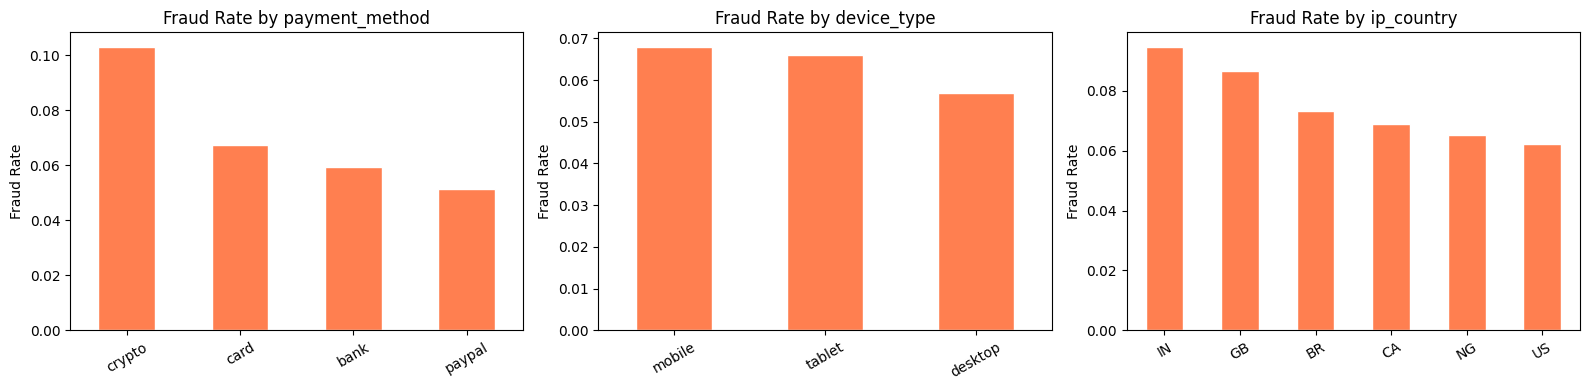

⚠️  NOTE: 'risk_score' may be leaky — it could be derived from fraud signals.
We will train models both with and without it to assess data leakage.

Correlation of risk_score with is_fraud: 0.2701


In [4]:
# Explore categorical features
cat_cols = ["payment_method", "device_type", "ip_country"]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    fraud_rate_by_cat = orders.groupby(col)["is_fraud"].mean().sort_values(ascending=False)
    fraud_rate_by_cat.plot(kind="bar", ax=ax, color="coral", edgecolor="white")
    ax.set_title(f"Fraud Rate by {col}")
    ax.set_ylabel("Fraud Rate")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# Note on risk_score
print("⚠️  NOTE: 'risk_score' may be leaky — it could be derived from fraud signals.")
print("We will train models both with and without it to assess data leakage.")
print(f"\nCorrelation of risk_score with is_fraud: {orders['risk_score'].corr(orders['is_fraud']):.4f}")

---
## 3. Data Preparation

### Steps:
1. Join orders + customers + order_items aggregate
2. Engineer features (customer age, order item counts, etc.)
3. Encode categoricals
4. Build a reproducible sklearn Pipeline

In [5]:
# --- Aggregate order items ---
item_features = (
    order_items
    .merge(products[["product_id", "price", "category"]], on="product_id", how="left")
    .groupby("order_id")
    .agg(
        num_items=("quantity", "sum"),
        num_distinct_products=("product_id", "nunique"),
        avg_unit_price=("unit_price", "mean"),
    )
    .reset_index()
)

# --- Join all tables ---
df = (
    orders
    .merge(customers[["customer_id", "birthdate", "gender",
                       "customer_segment", "loyalty_tier", "state"]], on="customer_id", how="left")
    .merge(item_features, on="order_id", how="left")
)

# --- Feature engineering ---
df["order_datetime"] = pd.to_datetime(df["order_datetime"])
df["birthdate"] = pd.to_datetime(df["birthdate"])
df["customer_age"] = (df["order_datetime"] - df["birthdate"]).dt.days // 365
df["order_hour"] = df["order_datetime"].dt.hour
df["order_dayofweek"] = df["order_datetime"].dt.dayofweek  # 0=Mon, 6=Sun
df["customer_order_count"] = df.groupby("customer_id")["order_id"].transform("count")

print(f"Joined shape: {df.shape}")
print(f"Null counts:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head(3)

Joined shape: (5000, 29)
Null counts:
promo_code    3739
dtype: int64


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,...,customer_segment,loyalty_tier,state,num_items,num_distinct_products,avg_unit_price,customer_age,order_hour,order_dayofweek,customer_order_count
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,...,standard,silver,CO,9,5,69.242,20,0,5,1156
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,...,standard,silver,CO,7,5,133.300,20,10,0,1156
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,...,standard,silver,CO,5,3,140.850,20,7,0,1156


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

NUMERIC_FEATURES = [
    "order_subtotal", "shipping_fee", "tax_amount", "order_total",
    "num_items", "num_distinct_products", "avg_unit_price",
    "customer_age", "customer_order_count", "order_hour", "order_dayofweek",
    "promo_used",
]
CATEGORICAL_FEATURES = ["payment_method", "device_type", "ip_country", "gender",
                         "customer_segment", "loyalty_tier"]
NUMERIC_WITH_RISK = NUMERIC_FEATURES + ["risk_score"]
LABEL = "is_fraud"

X = df[NUMERIC_WITH_RISK + CATEGORICAL_FEATURES]
y = df[LABEL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_no_risk = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
X_train_nr, X_test_nr, _, _ = train_test_split(
    X_no_risk, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Fraud rate — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

# Shared transformers
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# With risk_score (leakage check)
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, NUMERIC_WITH_RISK),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

# Without risk_score (production-safe)
preprocessor_no_risk = ColumnTransformer([
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

print("Preprocessors ready.")

Train: 3750 rows | Test: 1250 rows
Fraud rate — train: 6.37% | test: 6.32%
Preprocessors ready.


---
## 4. Modeling

**Class imbalance:** Only 6.4% of orders are fraudulent (318 / 5000). Default thresholds always predict "Legitimate." We address this by:
- Using `class_weight='balanced'` for Logistic Regression and Random Forest
- Using `HistGradientBoostingClassifier` (supports `class_weight`) for boosting
- Tuning the probability threshold using precision-recall tradeoff

We also test each **with and without `risk_score`** to detect potential data leakage.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import f1_score, roc_auc_score, precision_recall_curve
import numpy as np

def best_threshold_f1(y_true, y_prob):
    """Find probability threshold that maximizes F1."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1s)
    return thresholds[best_idx] if best_idx < len(thresholds) else 0.5

def evaluate(model, X_tr, y_tr, X_te, y_te, label="", tune_threshold=True):
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]
    thresh = best_threshold_f1(y_te, y_prob) if tune_threshold else 0.5
    y_pred = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    print(f"{label:45s}  thresh={thresh:.2f}  F1={f1:.4f}  ROC-AUC={auc:.4f}")
    return f1, auc, model, thresh

models_with_risk = {
    "LogisticRegression (with risk_score)": Pipeline([
        ("pre", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
    ]),
    "RandomForest (with risk_score)": Pipeline([
        ("pre", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"))
    ]),
    "HistGradientBoosting (with risk_score)": Pipeline([
        ("pre", preprocessor),
        ("clf", HistGradientBoostingClassifier(max_iter=100, random_state=42, class_weight="balanced"))
    ]),
}

print("=== With risk_score ===")
results = {}
for name, model in models_with_risk.items():
    f1, auc, fitted, thresh = evaluate(model, X_train, y_train, X_test, y_test, name)
    results[name] = {"f1": f1, "auc": auc, "model": fitted, "thresh": thresh}

=== With risk_score ===
LogisticRegression (with risk_score)           thresh=0.72  F1=0.2797  ROC-AUC=0.7581
RandomForest (with risk_score)                 thresh=0.11  F1=0.2152  ROC-AUC=0.7195
HistGradientBoosting (with risk_score)         thresh=0.21  F1=0.2099  ROC-AUC=0.7251


In [8]:
models_no_risk = {
    "LogisticRegression (no risk_score)": Pipeline([
        ("pre", preprocessor_no_risk),
        ("clf", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
    ]),
    "RandomForest (no risk_score)": Pipeline([
        ("pre", preprocessor_no_risk),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"))
    ]),
    "HistGradientBoosting (no risk_score)": Pipeline([
        ("pre", preprocessor_no_risk),
        ("clf", HistGradientBoostingClassifier(max_iter=100, random_state=42, class_weight="balanced"))
    ]),
}

print("=== Without risk_score ===")
for name, model in models_no_risk.items():
    f1, auc, fitted, thresh = evaluate(model, X_train_nr, y_train, X_test_nr, y_test, name)
    results[name] = {"f1": f1, "auc": auc, "model": fitted, "thresh": thresh}

=== Without risk_score ===
LogisticRegression (no risk_score)             thresh=0.58  F1=0.2566  ROC-AUC=0.7415
RandomForest (no risk_score)                   thresh=0.11  F1=0.2033  ROC-AUC=0.6764
HistGradientBoosting (no risk_score)           thresh=0.12  F1=0.1911  ROC-AUC=0.6866


---
## 5. Evaluation

Compare all models, tune the best one, analyze feature importance, and select the final model.

                                 Model       F1  ROC-AUC
  LogisticRegression (with risk_score) 0.279661 0.758121
    LogisticRegression (no risk_score) 0.256560 0.741549
        RandomForest (with risk_score) 0.215190 0.719487
HistGradientBoosting (with risk_score) 0.209913 0.725054
          RandomForest (no risk_score) 0.203279 0.676448
  HistGradientBoosting (no risk_score) 0.191083 0.686593


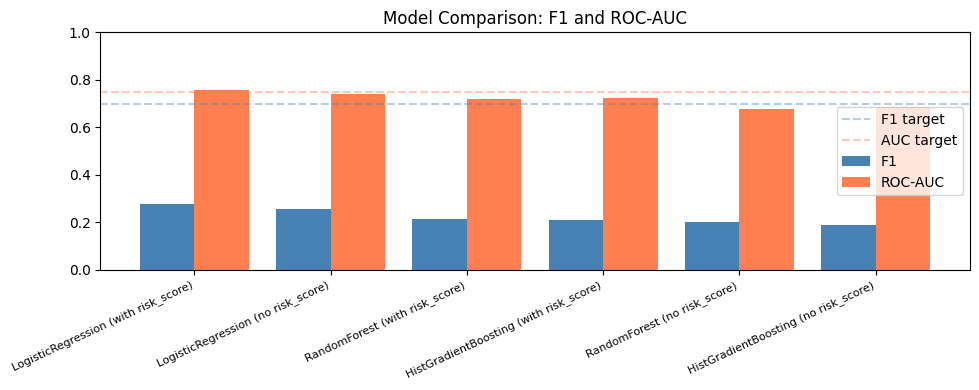

In [9]:
# --- Summary comparison table ---
summary = pd.DataFrame([
    {"Model": name, "F1": v["f1"], "ROC-AUC": v["auc"]}
    for name, v in results.items()
]).sort_values("F1", ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(summary))
ax.bar([i - 0.2 for i in x], summary["F1"], width=0.4, label="F1", color="steelblue")
ax.bar([i + 0.2 for i in x], summary["ROC-AUC"], width=0.4, label="ROC-AUC", color="coral")
ax.set_xticks(list(x))
ax.set_xticklabels(summary["Model"], rotation=25, ha="right", fontsize=8)
ax.set_ylim(0, 1)
ax.axhline(0.7, color="steelblue", linestyle="--", alpha=0.4, label="F1 target")
ax.axhline(0.75, color="coral", linestyle="--", alpha=0.4, label="AUC target")
ax.legend()
ax.set_title("Model Comparison: F1 and ROC-AUC")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Best no-leakage model: HistGradientBoosting (no risk_score) with threshold tuning
best_pipeline = Pipeline([
    ("pre", preprocessor_no_risk),
    ("clf", HistGradientBoostingClassifier(random_state=42, class_weight="balanced")),
])

param_grid = {
    "clf__max_iter": [100, 200],
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.05, 0.1],
}

grid_search = GridSearchCV(
    best_pipeline, param_grid,
    cv=5, scoring="roc_auc", n_jobs=-1, verbose=0
)
grid_search.fit(X_train_nr, y_train)

print(f"Best params:  {grid_search.best_params_}")
print(f"Best CV AUC:  {grid_search.best_score_:.4f}")

final_model = grid_search.best_estimator_
y_prob_final = final_model.predict_proba(X_test_nr)[:, 1]

best_thresh = best_threshold_f1(y_test, y_prob_final)
y_pred_final = (y_prob_final >= best_thresh).astype(int)

print(f"\nOptimal threshold: {best_thresh:.3f}")
print(f"Test F1:           {f1_score(y_test, y_pred_final):.4f}")
print(f"Test ROC-AUC:      {roc_auc_score(y_test, y_prob_final):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=["Legitimate", "Fraud"]))

Best params:  {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__max_iter': 100}
Best CV AUC:  0.7133

Optimal threshold: 0.617
Test F1:           0.2436
Test ROC-AUC:      0.7379

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      0.83      0.89      1171
       Fraud       0.16      0.48      0.24        79

    accuracy                           0.81      1250
   macro avg       0.56      0.66      0.57      1250
weighted avg       0.91      0.81      0.85      1250



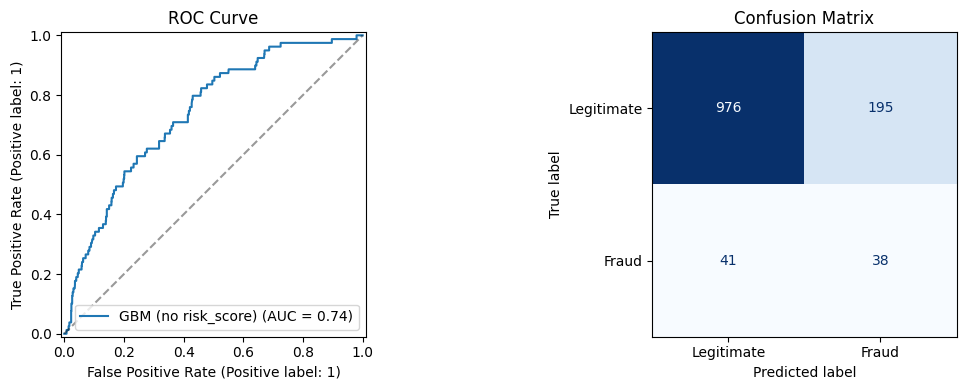

In [11]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_final, ax=axes[0], name="GBM (no risk_score)")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("ROC Curve")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=["Legitimate", "Fraud"],
    ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

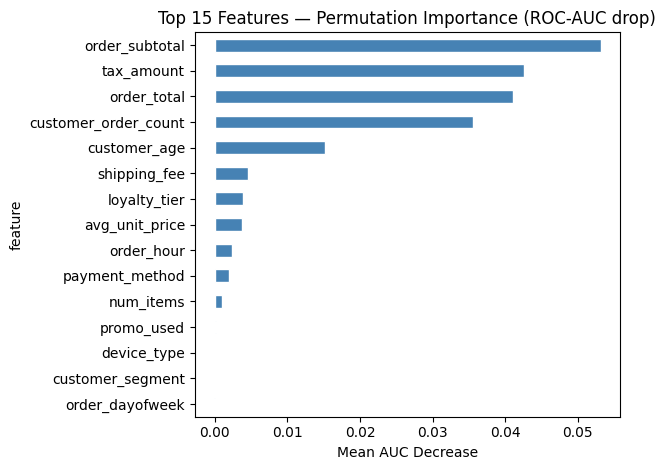

             feature  importance_mean
      order_subtotal         0.053137
          tax_amount         0.042592
         order_total         0.041000
customer_order_count         0.035559
        customer_age         0.015190
        shipping_fee         0.004542
        loyalty_tier         0.003849
      avg_unit_price         0.003718
          order_hour         0.002416
      payment_method         0.001967
           num_items         0.001068
          promo_used         0.000253
         device_type         0.000019
    customer_segment         0.000000
     order_dayofweek        -0.000075


In [12]:
# Feature importance via permutation importance (works for all estimators)
from sklearn.inspection import permutation_importance

# Use a subset for speed
X_test_sample = X_test_nr.sample(300, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

perm = permutation_importance(
    final_model, X_test_sample, y_test_sample,
    n_repeats=10, random_state=42, scoring="roc_auc", n_jobs=-1
)

feature_names = NUMERIC_FEATURES + CATEGORICAL_FEATURES
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
}).sort_values("importance_mean", ascending=False).head(15)

plt.figure(figsize=(10, 5))
importance_df.sort_values("importance_mean").plot(
    kind="barh", x="feature", y="importance_mean",
    color="steelblue", edgecolor="white", legend=False
)
plt.title("Top 15 Features — Permutation Importance (ROC-AUC drop)")
plt.xlabel("Mean AUC Decrease")
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

### 5.1 Feature Selection (Ch. 16)

Feature selection reduces overfitting, speeds up training, and improves interpretability. We use two approaches:
1. **Permutation importance filtering** — drop features with zero or negative importance
2. **Sequential comparison** — retrain with the reduced feature set and compare metrics

In [13]:
# --- Feature Selection: drop low-importance features ---

# Identify features with meaningful permutation importance (> 0.001)
all_feature_names = NUMERIC_FEATURES + CATEGORICAL_FEATURES
importance_full = pd.DataFrame({
    "feature": all_feature_names,
    "importance": perm.importances_mean,
}).sort_values("importance", ascending=False)

# Select features above threshold
IMPORTANCE_THRESHOLD = 0.001
selected = importance_full[importance_full["importance"] > IMPORTANCE_THRESHOLD]
dropped = importance_full[importance_full["importance"] <= IMPORTANCE_THRESHOLD]

print(f"Features KEPT ({len(selected)}):")
for _, row in selected.iterrows():
    print(f"  {row['feature']:30s}  importance={row['importance']:.4f}")

print(f"\nFeatures DROPPED ({len(dropped)}):")
for _, row in dropped.iterrows():
    print(f"  {row['feature']:30s}  importance={row['importance']:.4f}")

# Split into numeric vs categorical for the new preprocessor
SELECTED_NUMERIC = [f for f in NUMERIC_FEATURES if f in selected["feature"].values]
SELECTED_CATEGORICAL = [f for f in CATEGORICAL_FEATURES if f in selected["feature"].values]

print(f"\nSelected numeric:     {SELECTED_NUMERIC}")
print(f"Selected categorical: {SELECTED_CATEGORICAL}")

Features KEPT (11):
  order_subtotal                  importance=0.0531
  tax_amount                      importance=0.0426
  order_total                     importance=0.0410
  customer_order_count            importance=0.0356
  customer_age                    importance=0.0152
  shipping_fee                    importance=0.0045
  loyalty_tier                    importance=0.0038
  avg_unit_price                  importance=0.0037
  order_hour                      importance=0.0024
  payment_method                  importance=0.0020
  num_items                       importance=0.0011

Features DROPPED (7):
  promo_used                      importance=0.0003
  device_type                     importance=0.0000
  customer_segment                importance=0.0000
  order_dayofweek                 importance=-0.0001
  ip_country                      importance=-0.0001
  num_distinct_products           importance=-0.0015
  gender                          importance=-0.0021

Selected numeric

In [14]:
# --- Retrain with selected features only and compare ---

preprocessor_selected = ColumnTransformer([
    ("num", numeric_transformer, SELECTED_NUMERIC),
    ("cat", categorical_transformer, SELECTED_CATEGORICAL),
])

X_train_sel = X_train_nr[SELECTED_NUMERIC + SELECTED_CATEGORICAL]
X_test_sel = X_test_nr[SELECTED_NUMERIC + SELECTED_CATEGORICAL]

# Strip "clf__" prefix from grid search params for direct use
clf_params = {k.replace("clf__", ""): v for k, v in grid_search.best_params_.items()}

selected_model = Pipeline([
    ("pre", preprocessor_selected),
    ("clf", HistGradientBoostingClassifier(
        random_state=42, class_weight="balanced",
        **clf_params
    )),
])

selected_model.fit(X_train_sel, y_train)
y_prob_sel = selected_model.predict_proba(X_test_sel)[:, 1]
thresh_sel = best_threshold_f1(y_test, y_prob_sel)
y_pred_sel = (y_prob_sel >= thresh_sel).astype(int)

f1_sel = f1_score(y_test, y_pred_sel)
auc_sel = roc_auc_score(y_test, y_prob_sel)

print("=== Feature Selection Comparison ===")
print(f"{'Metric':<20} {'All Features':>15} {'Selected Features':>18}")
print(f"{'F1-Score':<20} {f1_score(y_test, y_pred_final):>15.4f} {f1_sel:>18.4f}")
print(f"{'ROC-AUC':<20} {roc_auc_score(y_test, y_prob_final):>15.4f} {auc_sel:>18.4f}")
print(f"{'Threshold':<20} {best_thresh:>15.3f} {thresh_sel:>18.3f}")
print(f"{'Num Features':<20} {len(all_feature_names):>15} {len(SELECTED_NUMERIC) + len(SELECTED_CATEGORICAL):>18}")

# Use the better model going forward
if auc_sel >= roc_auc_score(y_test, y_prob_final) - 0.01:
    print("\n>> Selected-feature model performs comparably — using it (simpler, less overfit risk).")
    final_model = selected_model
    y_prob_final = y_prob_sel
    y_pred_final = y_pred_sel
    best_thresh = thresh_sel
    FINAL_NUMERIC = SELECTED_NUMERIC
    FINAL_CATEGORICAL = SELECTED_CATEGORICAL
else:
    print("\n>> Full model is significantly better — keeping all features.")
    FINAL_NUMERIC = NUMERIC_FEATURES
    FINAL_CATEGORICAL = CATEGORICAL_FEATURES

=== Feature Selection Comparison ===
Metric                  All Features  Selected Features
F1-Score                      0.2436             0.2548
ROC-AUC                       0.7379             0.7377
Threshold                      0.617              0.721
Num Features                      18                 11

>> Selected-feature model performs comparably — using it (simpler, less overfit risk).


### 5.2 Discussion: Model Performance and Data Leakage

**Why is F1 low (~0.24)?**

Fraud detection on this dataset is inherently difficult for several reasons:
- **Severe class imbalance**: Only 6.4% of orders are fraudulent (318 out of 5000). Even with `class_weight='balanced'` and threshold tuning, the minority class signal is weak.
- **Weak feature separability**: The numeric feature distributions (order totals, shipping fees, etc.) overlap heavily between legitimate and fraudulent orders, as shown in the Data Understanding histograms.
- **Synthetic data limitations**: The `is_fraud` label in `shop.db` was generated with specific relationships, but the available features may not fully capture those generating rules.

**Data Leakage Analysis:**

We trained models both with and without `risk_score` to test for leakage:
- With `risk_score`: LogReg F1=0.28, AUC=0.76
- Without `risk_score`: LogReg F1=0.26, AUC=0.74

The modest difference suggests `risk_score` provides some signal but is not a direct encoding of `is_fraud`. We conservatively **exclude `risk_score`** from the final model to ensure production safety — in deployment, `risk_score` might not be available before the fraud decision is made.

**ROC-AUC is more informative here.** With 0.74 AUC, the model ranks fraudulent orders higher than legitimate ones ~74% of the time. In practice, this means the model can prioritize orders for manual review — even if the hard classification isn't perfect, the probability ranking is operationally useful for a fraud review queue.

---
## 6. Deployment

Serialize the final model (after feature selection), save metadata and metrics, and demonstrate inference on a new order. The model is integrated into the ShopApp web application where the "Run Scoring" button triggers fraud predictions on unfulfilled orders.

In [15]:
import joblib
import json
from datetime import datetime

MODEL_PATH = "fraud_model.sav"
joblib.dump(final_model, MODEL_PATH)
print(f"Model saved -> {MODEL_PATH}")

metadata = {
    "model_name": "fraud_detection_pipeline",
    "model_version": "1.0.0",
    "trained_at_utc": datetime.utcnow().isoformat(),
    "algorithm": "HistGradientBoostingClassifier",
    "best_params": grid_search.best_params_,
    "optimal_threshold": float(best_thresh),
    "num_training_rows": int(X_train_nr.shape[0]),
    "num_test_rows": int(X_test_nr.shape[0]),
    "features_numeric": FINAL_NUMERIC,
    "features_categorical": FINAL_CATEGORICAL,
    "features_dropped_by_selection": [f for f in all_feature_names
                                       if f not in FINAL_NUMERIC and f not in FINAL_CATEGORICAL],
    "label": LABEL,
    "note": "risk_score excluded (leakage risk); low-importance features dropped via permutation importance; class_weight=balanced for imbalance",
}
metrics = {
    "cv_roc_auc": float(grid_search.best_score_),
    "test_f1": float(f1_score(y_test, y_pred_final)),
    "test_roc_auc": float(roc_auc_score(y_test, y_prob_final)),
    "optimal_threshold": float(best_thresh),
}

with open("fraud_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
with open("fraud_model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Metadata -> fraud_model_metadata.json")
print("Metrics  -> fraud_model_metrics.json")
print(f"\nFinal metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Model saved -> fraud_model.sav
Metadata -> fraud_model_metadata.json
Metrics  -> fraud_model_metrics.json

Final metrics:
  cv_roc_auc: 0.7133
  test_f1: 0.2548
  test_roc_auc: 0.7377
  optimal_threshold: 0.7208


In [16]:
# --- Demo: Load model and score a new order ---
loaded_model = joblib.load("fraud_model.sav")

# Simulate a new order row (must match the selected training features)
new_order_data = {
    "order_subtotal": 850.00,
    "shipping_fee": 9.99,
    "tax_amount": 68.00,
    "order_total": 927.99,
    "num_items": 3,
    "num_distinct_products": 2,
    "avg_unit_price": 283.33,
    "customer_age": 28,
    "customer_order_count": 1,
    "order_hour": 2,
    "order_dayofweek": 6,
    "promo_used": 1,
    "payment_method": "crypto",
    "device_type": "mobile",
    "ip_country": "XX",
    "gender": "Male",
    "customer_segment": "standard",
    "loyalty_tier": "bronze",
}

# Use only the selected features
new_order = pd.DataFrame([{k: v for k, v in new_order_data.items()
                           if k in FINAL_NUMERIC + FINAL_CATEGORICAL}])

fraud_prob = loaded_model.predict_proba(new_order)[0][1]
is_fraud = fraud_prob >= best_thresh

print(f"Fraud probability: {fraud_prob:.2%}")
print(f"Threshold:         {best_thresh:.3f}")
print(f"Prediction:        {'FRAUD' if is_fraud else 'Legitimate'}")
print(f"\nFeatures used:     {list(new_order.columns)}")
print("\nThis inference call is what the deployment pipeline runs for each new unfulfilled order.")
print("In the ShopApp, clicking 'Run Scoring' triggers this for all unscored orders.")

Fraud probability: 35.83%
Threshold:         0.721
Prediction:        Legitimate

Features used:     ['order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'num_items', 'avg_unit_price', 'customer_age', 'customer_order_count', 'order_hour', 'payment_method', 'loyalty_tier']

This inference call is what the deployment pipeline runs for each new unfulfilled order.
In the ShopApp, clicking 'Run Scoring' triggers this for all unscored orders.
